In [1]:
from pathlib import Path

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

processed_data_path = (
    project_root
    / "data"
    / "processed"
    / "heart_disease_clean.csv"
)

if not processed_data_path.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found: {processed_data_path}"
    )

df = pd.read_csv(processed_data_path)

target_column = "heart_disease"

if target_column not in df.columns:
    raise KeyError(
        f"Target column '{target_column}' was not found"
    )

if df[target_column].isna().any():
    raise ValueError(
        "The target column contains missing values"
    )

X = df.drop(columns=[target_column])
y = df[target_column].astype("int64")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dataset loaded successfully")
print("Full dataset shape:", df.shape)
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training positive rate:", round(y_train.mean() * 100, 2), "%")
print("Testing positive rate:", round(y_test.mean() * 100, 2), "%")

Dataset loaded successfully
Full dataset shape: (4238, 16)
Training feature shape: (3390, 15)
Testing feature shape: (848, 15)
Training positive rate: 15.19 %
Testing positive rate: 15.21 %


In [2]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

continuous_features = [
    "age",
    "cigarettes_per_day",
    "total_cholesterol",
    "systolic_bp",
    "diastolic_bp",
    "bmi",
    "heart_rate",
    "glucose"
]

binary_features = [
    "current_smoker",
    "bp_meds",
    "prevalent_stroke",
    "prevalent_hypertension",
    "diabetes"
]

categorical_features = [
    "gender",
    "education"
]

all_defined_features = (
    continuous_features
    + binary_features
    + categorical_features
)

missing_features = sorted(
    set(X_train.columns) - set(all_defined_features)
)

unexpected_features = sorted(
    set(all_defined_features) - set(X_train.columns)
)

duplicate_features = [
    feature
    for feature in set(all_defined_features)
    if all_defined_features.count(feature) > 1
]

if missing_features:
    raise ValueError(
        f"Features not assigned to a group: {missing_features}"
    )

if unexpected_features:
    raise ValueError(
        f"Defined features not found: {unexpected_features}"
    )

if duplicate_features:
    raise ValueError(
        f"Features defined more than once: {duplicate_features}"
    )

logistic_continuous_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

tree_continuous_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

binary_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            logistic_continuous_pipeline,
            continuous_features
        ),
        (
            "binary",
            clone(binary_pipeline),
            binary_features
        ),
        (
            "categorical",
            clone(categorical_pipeline),
            categorical_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            tree_continuous_pipeline,
            continuous_features
        ),
        (
            "binary",
            clone(binary_pipeline),
            binary_features
        ),
        (
            "categorical",
            clone(categorical_pipeline),
            categorical_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

print("Preprocessing pipelines created successfully")
print("Continuous features:", len(continuous_features))
print("Binary features:", len(binary_features))
print("Categorical features:", len(categorical_features))
print("Total features:", len(all_defined_features))

Preprocessing pipelines created successfully
Continuous features: 8
Binary features: 5
Categorical features: 2
Total features: 15


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic Regression": Pipeline(
        steps=[
            (
                "preprocessor",
                clone(logistic_preprocessor)
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    random_state=42
                )
            )
        ]
    ),

    "Decision Tree": Pipeline(
        steps=[
            (
                "preprocessor",
                clone(tree_preprocessor)
            ),
            (
                "classifier",
                DecisionTreeClassifier(
                    random_state=42
                )
            )
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            (
                "preprocessor",
                clone(tree_preprocessor)
            ),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=300,
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )
}

print("Model pipelines created successfully")

for model_name in models:
    print("-", model_name)

Model pipelines created successfully
- Logistic Regression
- Decision Tree
- Random Forest


In [4]:
model_outputs = {}

for model_name, model_pipeline in models.items():
    training_start = time.perf_counter()

    model_pipeline.fit(
        X_train,
        y_train
    )

    training_end = time.perf_counter()

    prediction_start = time.perf_counter()

    train_predictions = model_pipeline.predict(
        X_train
    )

    test_predictions = model_pipeline.predict(
        X_test
    )

    train_probabilities = model_pipeline.predict_proba(
        X_train
    )[:, 1]

    test_probabilities = model_pipeline.predict_proba(
        X_test
    )[:, 1]

    prediction_end = time.perf_counter()

    model_outputs[model_name] = {
        "pipeline": model_pipeline,
        "train_predictions": train_predictions,
        "test_predictions": test_predictions,
        "train_probabilities": train_probabilities,
        "test_probabilities": test_probabilities,
        "training_time": training_end - training_start,
        "prediction_time": prediction_end - prediction_start
    }

    print(f"{model_name} completed.")
    print(
        f"  Training time: "
        f"{model_outputs[model_name]['training_time']:.4f} seconds"
    )
    print(
        f"  Prediction time: "
        f"{model_outputs[model_name]['prediction_time']:.4f} seconds"
    )
    print(
        "  Predicted positive test cases:",
        int(test_predictions.sum())
    )

Logistic Regression completed.
  Training time: 0.0449 seconds
  Prediction time: 0.0180 seconds
  Predicted positive test cases: 18
Decision Tree completed.
  Training time: 0.0266 seconds
  Prediction time: 0.0184 seconds
  Predicted positive test cases: 153
Random Forest completed.
  Training time: 0.5185 seconds
  Prediction time: 0.3125 seconds
  Predicted positive test cases: 17


In [5]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

evaluation_rows = []

for model_name, output in model_outputs.items():
    datasets = [
        (
            "Training",
            y_train,
            output["train_predictions"],
            output["train_probabilities"]
        ),
        (
            "Testing",
            y_test,
            output["test_predictions"],
            output["test_probabilities"]
        )
    ]

    for (
        dataset_name,
        actual_values,
        predicted_values,
        probability_values
    ) in datasets:

        evaluation_rows.append({
            "Model": model_name,
            "Dataset": dataset_name,
            "Accuracy": accuracy_score(
                actual_values,
                predicted_values
            ),
            "Precision": precision_score(
                actual_values,
                predicted_values,
                zero_division=0
            ),
            "Recall": recall_score(
                actual_values,
                predicted_values,
                zero_division=0
            ),
            "F1 Score": f1_score(
                actual_values,
                predicted_values,
                zero_division=0
            ),
            "ROC-AUC": roc_auc_score(
                actual_values,
                probability_values
            ),
            "PR-AUC": average_precision_score(
                actual_values,
                probability_values
            ),
            "Training Time": output["training_time"],
            "Prediction Time": output["prediction_time"]
        })

evaluation_results = pd.DataFrame(
    evaluation_rows
)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC",
    "Training Time",
    "Prediction Time"
]

evaluation_display = evaluation_results.copy()

evaluation_display[metric_columns] = (
    evaluation_display[metric_columns].round(4)
)

display(evaluation_display)

test_results = (
    evaluation_results[
        evaluation_results["Dataset"] == "Testing"
    ]
    .copy()
    .reset_index(drop=True)
)

print("Testing results:")

display(
    test_results.round(4)
)

,Model,Dataset,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Training Time,Prediction Time
0,Logistic Regression,Training,0.8572,0.7313,0.0951,0.1684,0.7423,0.3787,0.0449,0.0180
1,Logistic Regression,Testing,0.8432,0.3889,0.0543,0.0952,0.6952,0.2937,0.0449,0.0180
2,Decision Tree,Training,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0266,0.0184
3,Decision Tree,Testing,0.7311,0.1765,0.2093,0.1915,0.5170,0.1572,0.0266,0.0184
4,Random Forest,Training,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.5185,0.3125
5,Random Forest,Testing,0.8396,0.2941,0.0388,0.0685,0.6552,0.2341,0.5185,0.3125


Testing results:


,Model,Dataset,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Training Time,Prediction Time
0,Logistic Regression,Testing,0.8432,0.3889,0.0543,0.0952,0.6952,0.2937,0.0449,0.0180
1,Decision Tree,Testing,0.7311,0.1765,0.2093,0.1915,0.5170,0.1572,0.0266,0.0184
2,Random Forest,Testing,0.8396,0.2941,0.0388,0.0685,0.6552,0.2341,0.5185,0.3125


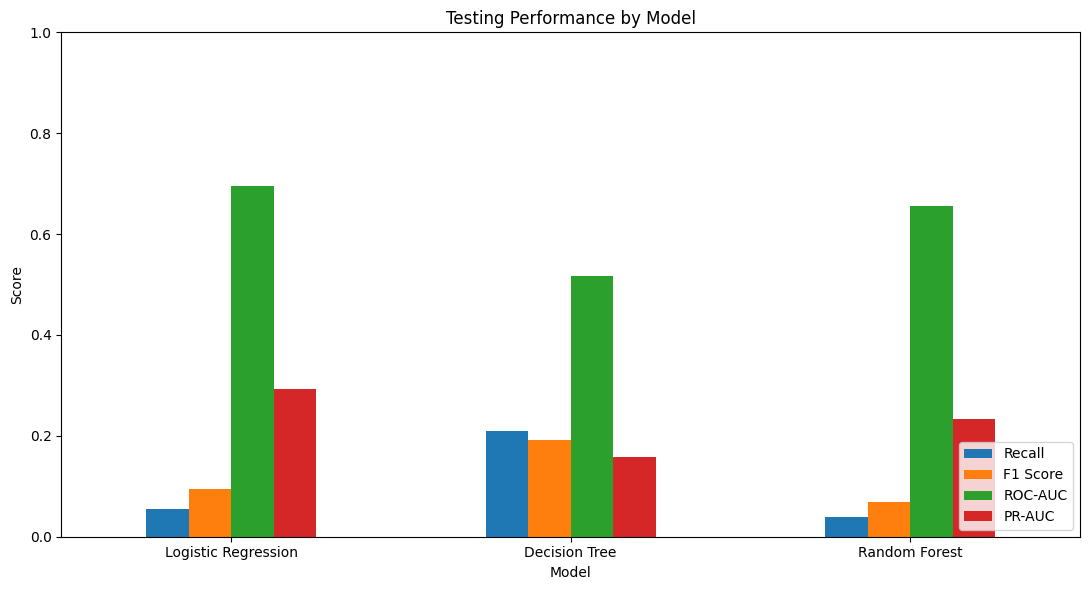

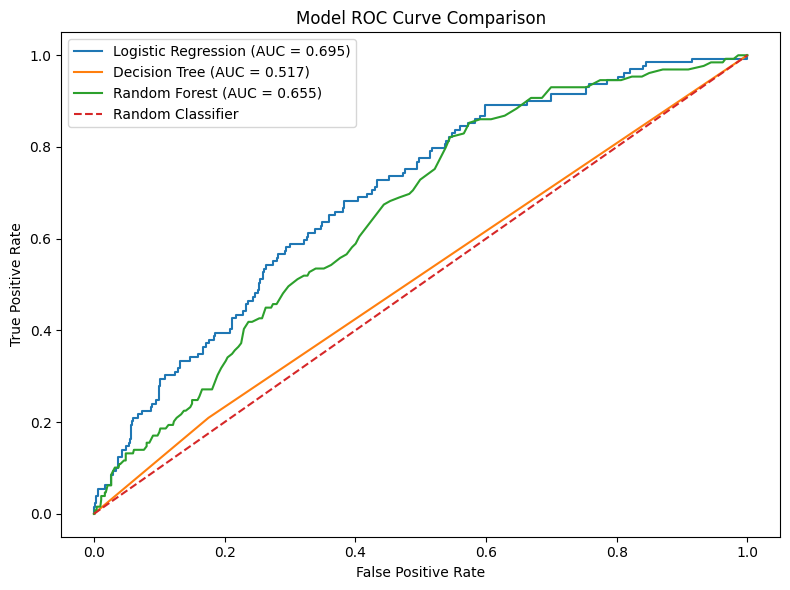

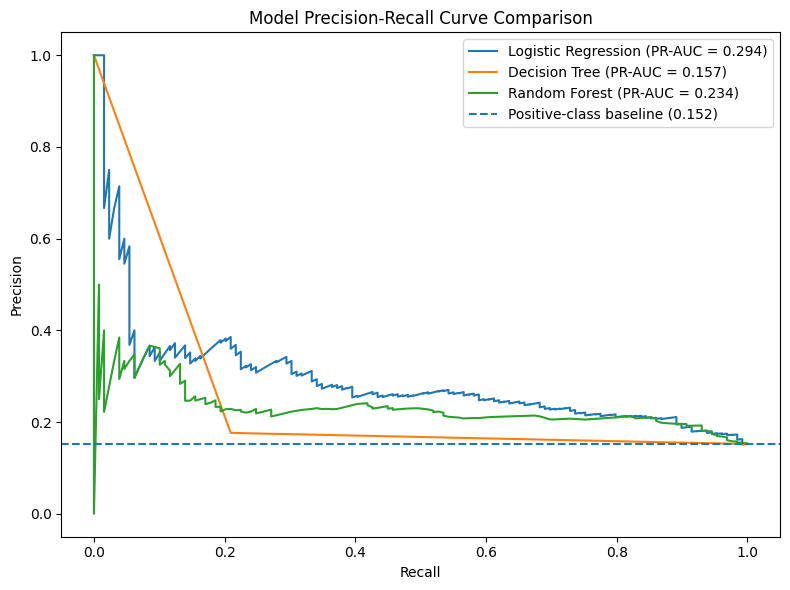

In [6]:
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve
)

comparison_metrics = (
    test_results
    .set_index("Model")[
        [
            "Recall",
            "F1 Score",
            "ROC-AUC",
            "PR-AUC"
        ]
    ]
)

comparison_metrics.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Testing Performance by Model")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))

for model_name, output in model_outputs.items():
    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            y_test,
            output["test_probabilities"]
        )
    )

    model_roc_auc = roc_auc_score(
        y_test,
        output["test_probabilities"]
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=(
            f"{model_name} "
            f"(AUC = {model_roc_auc:.3f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("Model ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))

positive_class_baseline = y_test.mean()

for model_name, output in model_outputs.items():
    curve_precision, curve_recall, _ = (
        precision_recall_curve(
            y_test,
            output["test_probabilities"]
        )
    )

    model_pr_auc = average_precision_score(
        y_test,
        output["test_probabilities"]
    )

    plt.plot(
        curve_recall,
        curve_precision,
        label=(
            f"{model_name} "
            f"(PR-AUC = {model_pr_auc:.3f})"
        )
    )

plt.axhline(
    positive_class_baseline,
    linestyle="--",
    label=(
        f"Positive-class baseline "
        f"({positive_class_baseline:.3f})"
    )
)

plt.title("Model Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
ranked_results = (
    test_results
    .sort_values(
        by=[
            "PR-AUC",
            "ROC-AUC",
            "Recall",
            "F1 Score"
        ],
        ascending=[
            False,
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

ranked_results.insert(
    0,
    "Rank",
    range(1, len(ranked_results) + 1)
)

best_model_name = ranked_results.loc[
    0,
    "Model"
]

best_model_pipeline = model_outputs[
    best_model_name
]["pipeline"]

best_model_result = ranked_results.iloc[0]

print("Final model ranking:")

display(
    ranked_results.round(4)
)

print("\nSelected model:", best_model_name)
print(
    "Selected model PR-AUC:",
    round(best_model_result["PR-AUC"], 4)
)
print(
    "Selected model ROC-AUC:",
    round(best_model_result["ROC-AUC"], 4)
)
print(
    "Selected model recall:",
    round(best_model_result["Recall"], 4)
)
print(
    "Selected model F1 score:",
    round(best_model_result["F1 Score"], 4)
)

reports_directory = project_root / "reports"
reports_directory.mkdir(
    parents=True,
    exist_ok=True
)

comparison_report_path = (
    reports_directory
    / "model_comparison.csv"
)

selection_report_path = (
    reports_directory
    / "final_model_selection.txt"
)

ranked_results.to_csv(
    comparison_report_path,
    index=False
)

selection_report = (
    f"Selected Model: {best_model_name}\n"
    f"Primary Selection Metric: PR-AUC\n"
    f"PR-AUC: {best_model_result['PR-AUC']:.4f}\n"
    f"ROC-AUC: {best_model_result['ROC-AUC']:.4f}\n"
    f"Recall: {best_model_result['Recall']:.4f}\n"
    f"F1 Score: {best_model_result['F1 Score']:.4f}\n"
    f"Accuracy: {best_model_result['Accuracy']:.4f}\n"
    f"Precision: {best_model_result['Precision']:.4f}\n"
)

selection_report_path.write_text(
    selection_report,
    encoding="utf-8"
)

print("\nComparison report saved to:")
print(comparison_report_path)

print("\nSelection report saved to:")
print(selection_report_path)

Final model ranking:


,Rank,Model,Dataset,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Training Time,Prediction Time
0,1,Logistic Regression,Testing,0.8432,0.3889,0.0543,0.0952,0.6952,0.2937,0.0449,0.0180
1,2,Random Forest,Testing,0.8396,0.2941,0.0388,0.0685,0.6552,0.2341,0.5185,0.3125
2,3,Decision Tree,Testing,0.7311,0.1765,0.2093,0.1915,0.5170,0.1572,0.0266,0.0184



Selected model: Logistic Regression
Selected model PR-AUC: 0.2937
Selected model ROC-AUC: 0.6952
Selected model recall: 0.0543
Selected model F1 score: 0.0952

Comparison report saved to:
c:\Users\User\OneDrive\Desktop\Heart-Disease-Classification\reports\model_comparison.csv

Selection report saved to:
c:\Users\User\OneDrive\Desktop\Heart-Disease-Classification\reports\final_model_selection.txt
